# Experiment No: 12
**Aim:** To implement Generative AI using a Generative Adversarial Network (GAN) to generate synthetic handwritten digits based on the MNIST dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU
from tensorflow.keras.datasets import mnist

print("--- Step 1: Load and Normalize Data ---")
(X_train, _), (_, _) = mnist.load_data()

# Normalize pixel values to between -1 and 1
X_train = (X_train.astype(np.float32) - 127.5) / 127.5
X_train = np.expand_dims(X_train, axis=3)

print("Training Data Shape:", X_train.shape)

--- Step 1: Load and Normalize Data ---
Training Data Shape: (60000, 28, 28, 1)


In [2]:
print("--- Step 2: Build Discriminator ---")
discriminator = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(512),
    LeakyReLU(alpha=0.2),
    Dense(256),
    LeakyReLU(alpha=0.2),
    Dense(1, activation='sigmoid')
])

discriminator.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
discriminator.summary()

--- Step 2: Build Discriminator ---


C:\Users\Divyanshu\Desktop\ML Lab\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Divyanshu\Desktop\ML Lab\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
print("\n--- Step 3 & 4: Build Generator and Combined GAN ---")
noise_dim = 100

generator = Sequential([
    Dense(256, input_dim=noise_dim),
    LeakyReLU(alpha=0.2),
    Dense(512),
    LeakyReLU(alpha=0.2),
    Dense(28 * 28 * 1, activation='tanh'),
    Reshape((28, 28, 1))
])

# Freeze Discriminator when training the Generator
discriminator.trainable = False

# Combine into a single GAN model
gan = Sequential([generator, discriminator])
gan.compile(loss='binary_crossentropy', optimizer='adam')
print("GAN Assembled successfully.")


--- Step 3 & 4: Build Generator and Combined GAN ---
GAN Assembled successfully.


C:\Users\Divyanshu\Desktop\ML Lab\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
print("--- Step 5: Training Loop (Running for 1000 batches) ---")
# Note: Real GANs train for thousands of epochs. We use a small loop for lab demonstration.
epochs = 1000
batch_size = 64
half_batch = batch_size // 2

for epoch in range(epochs):
    # 1. Train Discriminator
    idx = np.random.randint(0, X_train.shape[0], half_batch)
    real_images = X_train[idx]

    noise = np.random.normal(0, 1, (half_batch, noise_dim))
    fake_images = generator.predict(noise, verbose=0)

    # Real = 1, Fake = 0
    d_loss_real = discriminator.train_on_batch(real_images, np.ones((half_batch, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_images, np.zeros((half_batch, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # 2. Train Generator
    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    # We want the generator to fool the discriminator, so we label fakes as '1' (Real) here
    valid_y = np.array([1] * batch_size)
    g_loss = gan.train_on_batch(noise, valid_y)

    if epoch % 200 == 0:
        print(f"Batch {epoch} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]")

print("Training Complete!")

--- Step 5: Training Loop (Running for 1000 batches) ---


C:\Users\Divyanshu\Desktop\ML Lab\.venv\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Batch 0 [D loss: 0.4149, acc.: 85.16%] [G loss: 0.6726]
Batch 200 [D loss: 7.5511, acc.: 48.98%] [G loss: 0.0045]
Batch 400 [D loss: 7.7231, acc.: 48.82%] [G loss: 0.0023]
Batch 600 [D loss: 7.7831, acc.: 48.83%] [G loss: 0.0015]
Batch 800 [D loss: 7.8157, acc.: 48.80%] [G loss: 0.0011]
Training Complete!


--- Step 6: Visualizing Generated (Fake) Digits ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


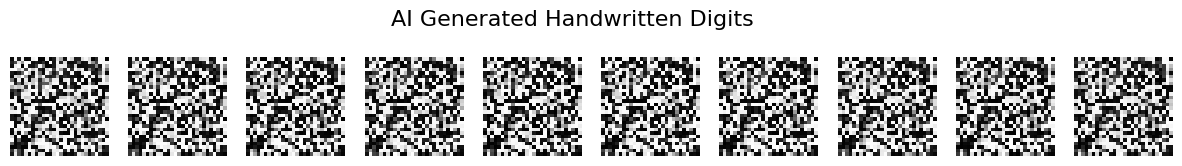

In [5]:
print("--- Step 6: Visualizing Generated (Fake) Digits ---")
# Generate 10 images from random noise
noise = np.random.normal(0, 1, (10, noise_dim))
generated_images = generator.predict(noise)

# Rescale images from [-1, 1] back to [0, 1] for displaying
generated_images = 0.5 * generated_images + 0.5

fig, axs = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axs[i].imshow(generated_images[i, :, :, 0], cmap='gray')
    axs[i].axis('off')

plt.suptitle("AI Generated Handwritten Digits", fontsize=16)
plt.show()